<a href="https://colab.research.google.com/github/GARVBALODI/Data_Science_Projects/blob/main/Mall_Customer_KMeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import the pandas library, commonly used for data manipulation and analysis
import pandas as pd
# Import the numpy library, essential for numerical operations, especially with arrays
import numpy as np
# Import KMeans from scikit-learn, which is the algorithm used for clustering
from sklearn.cluster import KMeans
# Import matplotlib.pyplot, a widely used library for creating static, animated, and interactive visualizations in Python
import matplotlib.pyplot as plt

In [2]:
# Import the 'files' module from google.colab, which provides utilities for interacting with the Colab environment, including file uploads.
from google.colab import files

# Call the 'upload()' method from the 'files' module.
# This will open a file picker dialog in your browser, allowing you to select and upload a local file to the Colab runtime.
# The uploaded files are stored in a dictionary where keys are filenames and values are their content.
uploaded = files.upload()

# Iterate through the keys (filenames) of the 'uploaded' dictionary.
# This loop is used to confirm which files were successfully uploaded and their sizes.
for filename in uploaded.keys():
  # Print a confirmation message showing the name and size of each uploaded file.
  # This helps verify the upload process.
  print(f'User uploaded file "{filename}" with length {len(uploaded[filename])} bytes')

Saving Mall_Customers.csv to Mall_Customers.csv
User uploaded file "Mall_Customers.csv" with length 4286 bytes


In [3]:
# Use the pandas library to read the CSV file located at "/content/Mall_Customers.csv".
# The '/content/' directory is the default location for uploaded files in Google Colab.
# The data from the CSV file is loaded into a pandas DataFrame named 'df'.
df = pd.read_csv("/content/Mall_Customers.csv")
# Display the first 5 rows of the DataFrame 'df'.
# This provides a quick overview of the data structure and its contents, helping to confirm successful loading.
display(df.head())

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
# Call the 'info()' method on the DataFrame 'df'.
# This method prints a concise summary of the DataFrame, including the index dtype and column dtypes, non-null values, and memory usage.
# It is crucial for understanding the data types of each column and identifying any missing values at a high level.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [5]:
# Call the 'isnull()' method on the DataFrame 'df' to create a boolean DataFrame indicating where values are missing (True for NaN, False otherwise).
# Then, chain the 'sum()' method to count the number of True values (missing values) for each column.
# This provides a clear summary of how many null values are present in each feature, which is important for data cleaning.
df.isnull().sum()

,0
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [6]:
# Call the 'describe()' method on the DataFrame 'df'.
# This method generates descriptive statistics that summarize the central tendency, dispersion, and shape of a dataset's distribution, excluding NaN values.
# For numerical data, it provides count, mean, standard deviation, minimum, maximum, and quartile values.
# This is useful for gaining quick insights into the distribution of numerical features.
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [7]:
# Select specific columns from the DataFrame 'df' to be used as features for clustering.
# Here, 'Annual Income (k$)' and 'Spending Score (1-100)' are chosen, as these are the variables we want to segment customers by.
# The selected columns form a new DataFrame 'X'.
X = df[['Annual Income (k$)' , 'Spending Score (1-100)']]
# Display the first 5 rows of the new DataFrame 'X'.
# This allows for a quick check of the features selected for the clustering model.
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


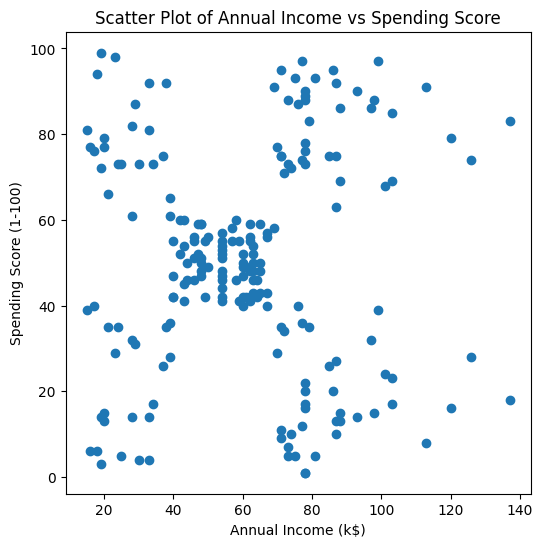

In [8]:
# Set the figure size for the plot to 6x6 inches, which provides a good balance for visibility.
plt.figure(figsize=(6,6))
# Create a scatter plot using 'Annual Income (k$)' for the x-axis and 'Spending Score (1-100)' for the y-axis.
# This initial plot helps visualize the raw distribution of customers before clustering.
plt.scatter(X['Annual Income (k$)'], X['Spending Score (1-100)'])

# Label the x-axis to clearly indicate that it represents 'Annual Income (k$)'.
plt.xlabel('Annual Income (k$)')
# Label the y-axis to clearly indicate that it represents 'Spending Score (1-100)'.
plt.ylabel('Spending Score (1-100)')
# Set the title of the plot to provide context, explaining what the scatter plot is showing.
plt.title('Scatter Plot of Annual Income vs Spending Score')
# Display the generated plot.
plt.show()

In [9]:
# Initialize the KMeans clustering algorithm from scikit-learn.
# 'n_clusters=5' specifies that we want to partition the data into 5 distinct groups (clusters).
# The KMeans algorithm aims to minimize the within-cluster sum of squares.
KMeans_model = KMeans(n_clusters=5)
# Fit the KMeans model to the data in DataFrame 'X'.
# This step performs the clustering, identifying the 5 clusters and their centroids based on the 'Annual Income (k$)' and 'Spending Score (1-100)' features.
KMeans_model.fit(X)

KMeans(n_clusters=5)

In [10]:
# Use the trained KMeans model to predict the cluster for each data point (customer) in 'X'.
# The 'predict()' method assigns each customer to one of the 5 clusters based on its proximity to the cluster centroids.
# The results are stored in the 'clusters' variable as an array of cluster labels.
clusters = KMeans_model.predict(X)
# Display the 'clusters' array.
# This shows the assigned cluster ID (0 through 4) for each customer in the original dataset.
clusters

array([2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3,
       2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 1,
       2, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 4, 0, 4, 1, 4, 0, 4, 0, 4,
       1, 4, 0, 4, 0, 4, 0, 4, 0, 4, 1, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4,
       0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4,
       0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4,
       0, 4], dtype=int32)

In [11]:
# Add a new column named 'Cluster' to the original DataFrame 'df'.
# This column stores the cluster ID assigned to each customer by the KMeans model.
# This integrates the clustering results back into the main dataset for further analysis.
df['Cluster'] = clusters
# Display the first few rows of the updated DataFrame 'df'.
# This allows verification that the 'Cluster' column has been successfully added and its values are consistent.
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,2
1,2,Male,21,15,81,3
2,3,Female,20,16,6,2
3,4,Female,23,16,77,3
4,5,Female,31,17,40,2


In [12]:
# Access the 'cluster_centers_' attribute of the trained KMeans model.
# This attribute holds the coordinates of the center point (centroid) for each cluster found by the algorithm.
# Each row represents a cluster, and the columns represent the feature values (Annual Income, Spending Score) for that centroid.
KMeans_model.cluster_centers_

array([[88.2       , 17.11428571],
       [55.2962963 , 49.51851852],
       [26.30434783, 20.91304348],
       [25.72727273, 79.36363636],
       [86.53846154, 82.12820513]])

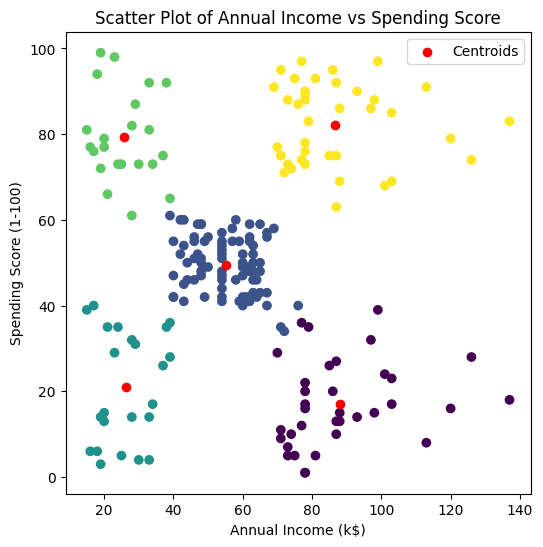

In [13]:
# Set the figure size for better visualization
plt.figure(figsize=(6,6))

# Create a scatter plot of Annual Income vs Spending Score
# Points are colored based on their assigned cluster from the KMeans model
plt.scatter(X['Annual Income (k$)'], X['Spending Score (1-100)'], c=df['Cluster'])

# Plot the cluster centroids (center points of each cluster)
# The centroids are extracted from the fitted KMeans model and colored red
plt.scatter(KMeans_model.cluster_centers_[:,0], KMeans_model.cluster_centers_[:,1], color='red', label='Centroids')

# Display a legend to identify the centroids
plt.legend()

# Set the label for the x-axis
plt.xlabel('Annual Income (k$)')

# Set the label for the y-axis
plt.ylabel('Spending Score (1-100)')

# Set the title of the scatter plot
plt.title('Scatter Plot of Annual Income vs Spending Score')

# Display the plot
plt.show()

In [14]:
# Iterate through each unique cluster ID, sorted numerically
for cluster in sorted(df['Cluster'].unique()):
  # Print the current cluster number to clearly separate outputs
  print(f'\nCluster {cluster}')
  # Filter the DataFrame to include only data points belonging to the current cluster
  # Then, generate and print descriptive statistics (mean, std, min, max, etc.) for these data points
  print(df[df['Cluster'] == cluster].describe())
  # Add an extra newline for better readability between cluster descriptions
  print('\n')


Cluster 0
       CustomerID        Age  Annual Income (k$)  Spending Score (1-100)  \
count   35.000000  35.000000           35.000000               35.000000   
mean   164.371429  41.114286           88.200000               17.114286   
std     21.457325  11.341676           16.399067                9.952154   
min    125.000000  19.000000           70.000000                1.000000   
25%    148.000000  34.000000           77.500000               10.000000   
50%    165.000000  42.000000           85.000000               16.000000   
75%    182.000000  47.500000           97.500000               23.500000   
max    199.000000  59.000000          137.000000               39.000000   

       Cluster  
count     35.0  
mean       0.0  
std        0.0  
min        0.0  
25%        0.0  
50%        0.0  
75%        0.0  
max        0.0  



Cluster 1
       CustomerID        Age  Annual Income (k$)  Spending Score (1-100)  \
count   81.000000  81.000000           81.000000              

In [15]:
# Select the 'Cluster' column from the DataFrame 'df'.
# Apply the 'value_counts()' method to this column.
# This method returns a Series containing counts of unique values in the 'Cluster' column, sorted in descending order by default.
# It effectively shows how many customers belong to each cluster, providing an overview of cluster sizes.
df['Cluster'].value_counts()

,count
Cluster,
1,81
4,39
0,35
2,23
3,22
